In [33]:
import pandas as pd
from torch.utils.data import Dataset, DataLoader, random_split
import torch
import numpy as np
from torch import nn
from torch.nn import CrossEntropyLoss
from torch.optim import Adam
from tqdm import tqdm
from sklearn.metrics import f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import imageio.v2 as imageio  # newer imageio version uses imageio.v2
import io

In [34]:
df = pd.read_parquet("../../data/processed/train.parquet")
df.head()

,features,label
0,"[[-0.755859375, 0.0, -0.59912109375, 0.0, -0.4...",1
1,"[[-0.5419921875, -0.58203125, -0.347900390625,...",3
2,"[[-1.0, 0.0, -0.783203125, 0.0, -0.5888671875,...",4
3,"[[0.08026123046875, 0.0, -0.421142578125, 0.0,...",6
4,"[[-0.79638671875, 0.0, -0.63818359375, 0.0, -0...",7


In [35]:
df.iloc[0]['features'][0]

array([-0.75585938,  0.        , -0.59912109,  0.        , -0.48852539,
        0.        , -0.44604492,  0.        , -0.42114258,  0.        ,
       -0.79003906,  0.        , -0.65429688,  0.        , -0.55664062,
        0.        , -0.49267578,  0.        , -0.875     ,  0.        ,
       -0.73925781,  0.        , -0.62841797,  0.        , -0.55273438,
        0.        , -0.91308594,  0.        , -0.79003906,  0.        ,
       -0.68408203,  0.        , -0.60742188,  0.        , -0.91308594,
        0.        , -0.81542969,  0.        , -0.7265625 ,  0.        ,
       -0.65429688,  0.        ,  1.        ,  0.        ,  0.92333984,
        0.        ,  0.81347656,  0.        ,  0.72851562,  0.        ,
        0.66455078,  0.        ,  0.69970703,  0.        ,  0.59814453,
        0.        ,  0.56298828,  0.        ,  0.5546875 ,  0.        ,
        0.69970703,  0.        ,  0.61035156,  0.        ,  0.57519531,
        0.        ,  0.56689453,  0.        ,  0.71191406,  0.  

In [36]:
max_seq_len = 0
for row in df['features']:
    if len(row) > max_seq_len:
        max_seq_len = len(row)
print(f"Max sequence lenght: {max_seq_len}")

Max sequence lenght: 100


In [37]:
class LandmarkDataset(Dataset):
    def __init__(self, dataset_path: str, max_seq_len: int = None):
        self.df = pd.read_parquet(dataset_path)
        if max_seq_len is None:
            max_seq_len = 0
            for row in self.df['features']:
                if len(row) > max_seq_len:
                    max_seq_len = len(row)
        self.max_seq_len = max_seq_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        features = self.df.iloc[idx]['features']
        label = self.df.iloc[idx]['label']
        
        tensors = [torch.from_numpy(a).float() for a in features]
        row_tensor = torch.stack(tensors)
        
        if len(row_tensor) < max_seq_len:
            pad_size = max_seq_len - len(row_tensor)
            padded = torch.cat([
                row_tensor, 
                torch.zeros(pad_size, 84)
            ], dim=0)
        elif len(row_tensor) > max_seq_len:
            padded = row_tensor[:max_seq_len]
        else:
            padded = row_tensor
        
        return padded, label    

In [38]:
train_dataset = LandmarkDataset("../../data/processed/train.parquet")
test_dataset = LandmarkDataset("../../data/processed/test.parquet")

test_size = int(len(test_dataset) * 0.5)
val_size = len(test_dataset) - test_size
    
test_dataset, val_dataset  = random_split(
        test_dataset, [test_size, val_size]
)

train_loader = DataLoader(
        train_dataset,
        batch_size=16,
        shuffle=True,
)
    
val_loader = DataLoader(
        val_dataset,
        batch_size=16
)

test_loader = DataLoader(
        test_dataset,
        batch_size=16
)

In [39]:
def save_confusion_matrices_as_gif(confusion_matrices, filename="confusion_evolution.gif", fps=1):
    """
    confusion_matrices: list of 2D numpy arrays (one per epoch)
    class_names: list of class names for labeling
    filename: output GIF file name
    fps: frames per second (animation speed)
    """
    images = []

    for i, cm in enumerate(confusion_matrices):
        # Create a Matplotlib figure
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.xlabel('Predicted', fontsize=12)
        plt.ylabel('True', fontsize=12)
        plt.title(f'Confusion Matrix – Epoch {i + 1}')
        plt.tight_layout()

        # Save current plot to an in-memory buffer
        buf = io.BytesIO()
        plt.savefig(buf, format='png')
        buf.seek(0)
        images.append(imageio.imread(buf))
        buf.close()
        plt.close()

    # Save all images as a GIF
    imageio.mimsave(filename, images, fps=fps)
    print(f"✅ Saved {filename} with {len(images)} frames.")

In [40]:
def test(
    model,
    loss_fn
):
    model.eval()
    test_loss = 0.0
    total_test = 0
    correct_test = 0
    
    all_preds = []
    all_labels = []
    
    with torch.inference_mode():
        for features, labels in (pbar := tqdm(test_loader, desc=f"Testing │", leave=False)):
            logits = model(features)
            loss = loss_fn(logits, labels)
            
            test_loss += loss.item() * features.size(0)
            total_test += labels.size(0)
            
            preds = torch.argmax(logits, dim=1)
            correct_test += (preds == labels).sum().item()
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            running_test_loss = test_loss / total_test
            pbar.set_postfix({"loss": f"{running_test_loss:.4f}"})
    
    avg_test_loss = test_loss / total_test
    test_acc = correct_test / total_test
    
    f1 = f1_score(all_labels, all_preds, average='weighted')
    cm = confusion_matrix(all_labels, all_preds)
    
    return {
        "test_loss": avg_test_loss,
        "test_acc": test_acc,
        "f1_score": f1,
        "confusion_matrix": cm
    }

In [41]:
def train(
    model,
    epochs,
    optimizer,
    loss_fn
):
    cms = []
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        correct_train = 0
        total_train = 0
        
        for features, labels in (pbar := tqdm(train_loader, desc=f"Epoch {epoch+1:3d}/{epochs} │ Training", leave=False)):
            optimizer.zero_grad()
            logits = model(features)
            loss = loss_fn(logits, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * features.size(0)
            total_train += labels.size(0)
            
            preds = torch.argmax(logits, dim=1)
            correct_train += (preds == labels).sum().item()
            
            running_loss = train_loss / total_train
            pbar.set_postfix({"loss": f"{running_loss:.4f}"})

        model.eval()
        val_loss = 0.0
        total_val = 0
        correct_val = 0
        
        with torch.inference_mode():
            cms.append(test(model, loss_fn)["confusion_matrix"])
            for features, labels in (pbar := tqdm(val_loader, desc=f"Epoch {epoch+1:3d}/{epochs} │ Validating", leave=False)):
                logits = model(features)
                loss = loss_fn(logits, labels)
                
                val_loss += loss.item() * features.size(0)
                total_val += labels.size(0)
                
                preds = torch.argmax(logits, dim=1)
                correct_val += (preds == labels).sum().item()
                
                running_val_loss = val_loss / total_val
                pbar.set_postfix({"loss": f"{running_val_loss:.4f}"})
        
        avg_train_loss = train_loss / total_train
        avg_val_loss = val_loss / total_val
        
        train_acc = correct_train / total_train
        val_acc = correct_val / total_val
        
        print(
            f"Epoch {epoch+1:3d}/{epochs} │ "
            f"Train Loss: {avg_train_loss:.4f} │ Val Loss: {avg_val_loss:.4f} │ "
            f"Train Acc: {train_acc:.4f} │ Val Acc: {val_acc:.4f}"
        )
    save_confusion_matrices_as_gif(cms)

In [42]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))
        pe = torch.zeros(max_len, 1, d_model)
        pe[:, 0, 0::2] = torch.sin(position * div_term)
        pe[:, 0, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(0)]
        return self.dropout(x)

In [43]:
class GestureTransformer(nn.Module):
    def __init__(
        self,
        num_classes: int = 33,
        d_model: int = 84,
        d_ff: int = 256,
        num_encoders: int = 3,
        nheads: int = 4, 
        dropout: float = 0.3 
    ):
        super().__init__()
        
        # Input projection
        self.input_proj = nn.Linear(84, d_model)
        self.pos_encoding = PositionalEncoding(d_model)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))
        
        # Transformer encoder only
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nheads,
            dim_feedforward=d_ff,
            dropout=dropout,
            activation="relu",
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer=encoder_layer,
            num_layers=num_encoders
        )
        
        # Classifier
        self.fc = nn.Linear(d_model, num_classes)
    
    def forward(self, x):
        batch_size = x.size(0)
        
        # Input projection
        x = self.input_proj(x)  # (batch, seq_len, d_model)
        x = self.pos_encoding(x)
        
        # Add CLS token
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)  # (batch, seq_len+1, d_model)
        
        # Transformer encoder
        encoded = self.transformer(x)  # (batch, seq_len+1, d_model)
        
        # Use CLS token for classification
        cls_output = encoded[:, 0, :]  # (batch, d_model)
        
        # Classification
        logits = self.fc(cls_output)  # (batch, num_classes)
        return logits

In [44]:
class GestureRNN(nn.Module):
    def __init__(
        self,
        num_classes: int = 33,
        d_model: int = 84,
        d_hidden: int = 128,
        num_layers: int = 3,
        dropout: float = 0.3
    ):
        super().__init__()  
        
        self.input_proj = nn.Linear(84, d_model)
        
        self.gru = nn.GRU(
            input_size=d_model,
            hidden_size=d_hidden,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        self.fc = nn.Linear(d_hidden, num_classes)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        # Input: (batch_size, seq_len, 84)
        x = self.input_proj(x)  # (batch_size, seq_len, d_model)
        
        # GRU forward
        output, hidden = self.gru(x)  # output: (batch_size, seq_len, d_hidden)
        
        # Use the last output of the sequence
        last_output = output[:, -1, :]  # (batch_size, d_hidden) - last timestep
        
        # Apply dropout and classify
        last_output = self.dropout(last_output)
        logits = self.fc(last_output)  # (batch_size, num_classes)
        
        return logits

In [45]:
class GestureCNN(nn.Module):
    def __init__(
        self,
        num_classes: int = 33,
        d_model: int = 84,
        d_hidden: int = 256,
        dropout: float = 0.3
    ):
        super().__init__()

        self.input_proj = nn.Linear(84, d_model)  
        
        # Convolution layers
        self.convs = nn.Sequential(
            # After input_proj: (batch, seq_len, d_model)  transpose  (batch, d_model, seq_len)
            nn.Conv1d(d_model, d_hidden, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),  # seq_len: 100 → 50
            
            nn.Conv1d(d_hidden, d_hidden * 2, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),  # seq_len: 50 → 25
            
            nn.Conv1d(d_hidden * 2, d_hidden * 4, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)  # (batch, d_hidden*4, 1)
        )   
        
        # Classifier - input size must match last conv layer output channels
        self.fc = nn.Linear(d_hidden * 4, num_classes)   
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        # x shape: (batch_size, seq_len=100, features=84)
        x = self.input_proj(x)  # (batch_size, 100, d_model)
        x = x.transpose(1, 2)   # (batch_size, d_model, 100)
        
        x = self.convs(x)       # (batch_size, d_hidden*4, 1)
        x = x.squeeze(-1)       # (batch_size, d_hidden*4)
        
        x = self.dropout(x)
        x = self.fc(x)          # (batch_size, num_classes)
        return x

In [46]:
print("Transformer")
model = GestureTransformer(
    num_classes=33,
    d_model=32,
    d_ff=32,
    num_encoders=2,
    nheads=2,
    dropout=0.3
)

optimizer = Adam(model.parameters(), lr=1e-3)
loss_fn = CrossEntropyLoss()

example_input = torch.randn(16, 12, 84)
logits = model(example_input)

print(logits.shape)
train(
    model=model,
    epochs=30,
    optimizer=optimizer,
    loss_fn=loss_fn
)

testing_results = test(  
    model=model,
    loss_fn=loss_fn
)

print(f"Testing loss:\t\t{testing_results["test_loss"]}")
print(f"Testing accuracy:\t{testing_results["test_acc"]}")
print(f"Testing F1:\t\t{testing_results["f1_score"]}")

plt.figure(figsize=(20, 20))
sns.heatmap(testing_results["confusion_matrix"], annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

Transformer
torch.Size([16, 33])


Epoch   1/30 │ Train Loss: 3.2611 │ Val Loss: 2.7703 │ Train Acc: 0.0631 │ Val Acc: 0.0000


Epoch   2/30 │ Train Loss: 2.4531 │ Val Loss: 2.1990 │ Train Acc: 0.1926 │ Val Acc: 0.2059


Epoch   3/30 │ Train Loss: 1.8990 │ Val Loss: 1.7248 │ Train Acc: 0.3470 │ Val Acc: 0.3824


Epoch   4/30 │ Train Loss: 1.5744 │ Val Loss: 1.5574 │ Train Acc: 0.4325 │ Val Acc: 0.4118


Epoch   5/30 │ Train Loss: 1.3691 │ Val Loss: 1.4913 │ Train Acc: 0.5052 │ Val Acc: 0.5000


KeyboardInterrupt: 

In [ ]:
print("RNN")
model = GestureRNN(
    num_classes=33,
    d_model=84,
    d_hidden=64,
    num_layers=2,
    dropout=0.3
)
optimizer = Adam(model.parameters(), lr=1e-3)
loss_fn = CrossEntropyLoss()

example_input = torch.randn(16, 100, 84)
logits = model(example_input)

print(logits.shape)
train(
    model=model,
    epochs=30,
    optimizer=optimizer,
    loss_fn=loss_fn
)

testing_results = test(  
    model=model,
    loss_fn=loss_fn
)

print(f"Testing loss:\t\t{testing_results["test_loss"]}")
print(f"Testing accuracy:\t{testing_results["test_acc"]}")
print(f"Testing F1:\t\t{testing_results["f1_score"]}")

plt.figure(figsize=(20, 20))
sns.heatmap(testing_results["confusion_matrix"], annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

RNN
torch.Size([16, 33])


Epoch   1/30 │ Train Loss: 3.4692 │ Val Loss: 3.4593 │ Train Acc: 0.0411 │ Val Acc: 0.0385


Epoch   2/30 │ Train Loss: 3.4390 │ Val Loss: 3.4228 │ Train Acc: 0.0433 │ Val Acc: 0.0593


Epoch   3/30 │ Train Loss: 3.3985 │ Val Loss: 3.3761 │ Train Acc: 0.0545 │ Val Acc: 0.0545


Epoch   4/30 │ Train Loss: 3.3647 │ Val Loss: 3.3507 │ Train Acc: 0.0623 │ Val Acc: 0.0609


...

Epoch  11/30 │ Train Loss: 3.1463 │ Val Loss: 3.1504 │ Train Acc: 0.1128 │ Val Acc: 0.1194


Epoch  12/30 │ Train Loss: 3.1178 │ Val Loss: 3.1316 │ Train Acc: 0.1231 │ Val Acc: 0.1122


Epoch  13/30 │ Train Loss: 3.0703 │ Val Loss: 3.0494 │ Train Acc: 0.1351 │ Val Acc: 0.1490


Epoch  14/30 │ Train Loss: 3.0272 │ Val Loss: 3.0512 │ Train Acc: 0.1393 │ Val Acc: 0.1330


KeyboardInterrupt: 

CNN
torch.Size([16, 33])


Epoch   1/5 │ Train Loss: 2.5026 │ Val Loss: 1.7574 │ Train Acc: 0.1966 │ Val Acc: 0.2647


Epoch   2/5 │ Train Loss: 1.1736 │ Val Loss: 1.6262 │ Train Acc: 0.5673 │ Val Acc: 0.5588


Epoch   3/5 │ Train Loss: 0.7544 │ Val Loss: 1.4669 │ Train Acc: 0.7222 │ Val Acc: 0.5882


Epoch   4/5 │ Train Loss: 0.5711 │ Val Loss: 1.4835 │ Train Acc: 0.7891 │ Val Acc: 0.7059


Epoch   5/5 │ Train Loss: 0.4533 │ Val Loss: 1.6587 │ Train Acc: 0.8464 │ Val Acc: 0.6471
✅ Saved confusion_evolution.gif with 5 frames.


Testing loss:		1.002031016417525
Testing accuracy:	0.7272727272727273
Testing F1:		0.7274170274170275


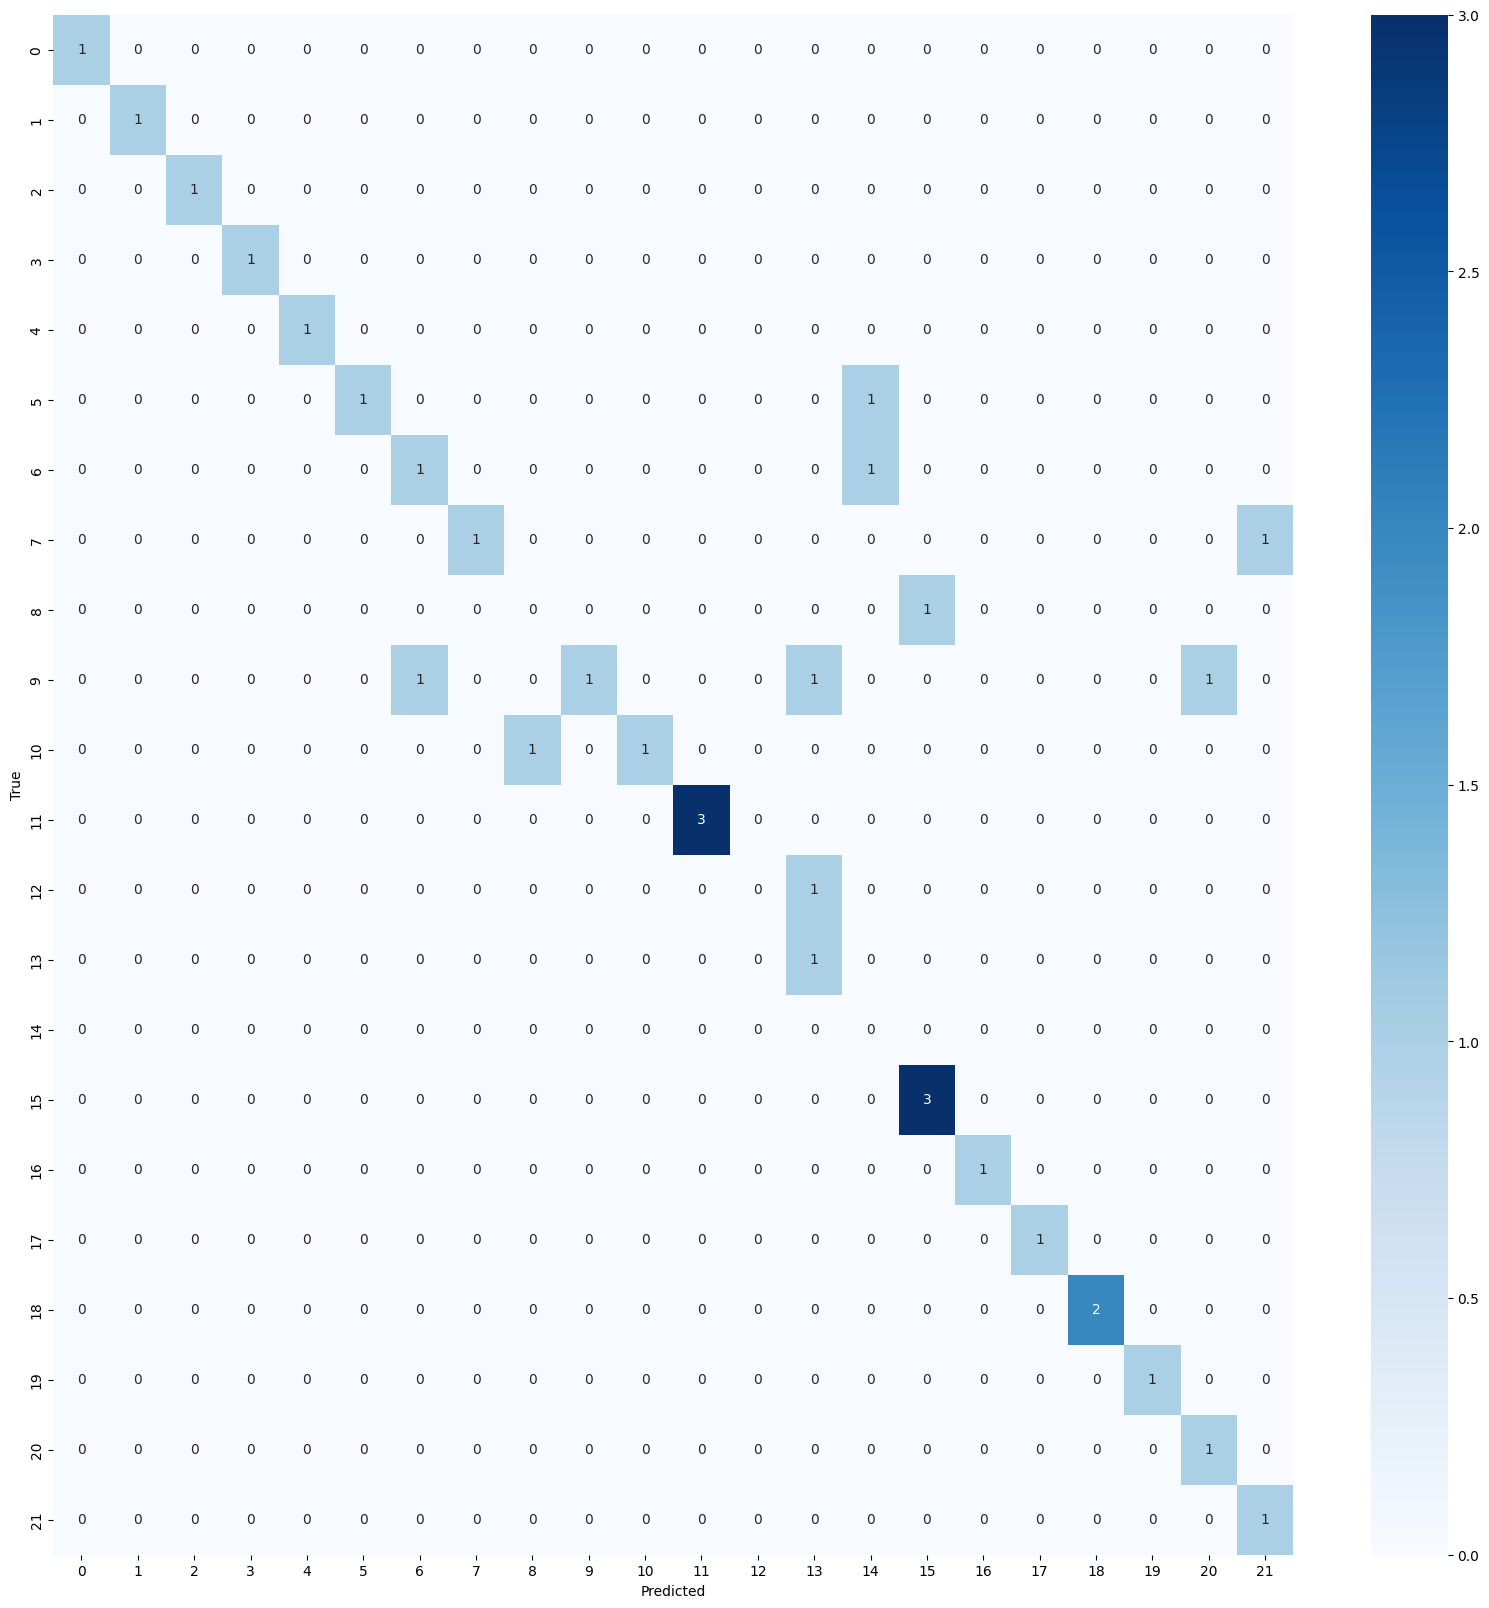

In [47]:
import warnings
warnings.filterwarnings("ignore")
print("CNN")
model = GestureCNN(
    num_classes=33,
    d_model=84,
    d_hidden=128,
    dropout=0.3
)
optimizer = Adam(model.parameters(), lr=1e-3)
loss_fn = CrossEntropyLoss()

example_input = torch.randn(16, 100, 84)
logits = model(example_input)

print(logits.shape)
train(
    model=model,
    epochs=5,
    optimizer=optimizer,
    loss_fn=loss_fn
)

testing_results = test(  
    model=model,
    loss_fn=loss_fn
)

print(f"Testing loss:\t\t{testing_results["test_loss"]}")
print(f"Testing accuracy:\t{testing_results["test_acc"]}")
print(f"Testing F1:\t\t{testing_results["f1_score"]}")

plt.figure(figsize=(20, 20))
sns.heatmap(testing_results["confusion_matrix"], annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()